# 04-Baseline_and_BO — Fail‑Fast + Training (Merged)
- **01–02 is the source of truth for labels** (no local LABEL_MAP here).
- **Fail fast** if persisted splits are missing / non-binary / mono‑class.
- **Always** load from `out/splits/*.parquet`.
- Training cells from legacy notebook are merged back in.


## 4.0 — Fail‑Fast Consistency Guard

In [134]:
# =====================================================
# 4.0 — Fail-Fast Consistency Guard (prefer persisted splits)
# =====================================================
from pathlib import Path
import numpy as np, pandas as pd

OUT_ROOT   = Path(globals().get("OUT_ROOT", "out"))
SPLITS_DIR = Path(globals().get("SPLITS_DIR", OUT_ROOT/"splits"))
TARGET_COL = globals().get("TARGET_COL", "label")

req = ["X_train.parquet","X_val.parquet","y_train.parquet","y_val.parquet","manifest.json"]
missing = [r for r in req if not (SPLITS_DIR / r).exists()]
assert not missing, f"[4.0] Missing persisted splits: {missing}. Run 01–02 first."

def _load_y(path):
    df = pd.read_parquet(path); col = TARGET_COL if TARGET_COL in df.columns else df.columns[0]
    return np.asarray(df[col]).ravel().astype(int)

# Always load from persisted splits
X_train = pd.read_parquet(SPLITS_DIR/"X_train.parquet")
X_val   = pd.read_parquet(SPLITS_DIR/"X_val.parquet")
y_train = _load_y(SPLITS_DIR/"y_train.parquet")
y_val   = _load_y(SPLITS_DIR/"y_val.parquet")

# Ensure both classes exist (mono-class would break CV/metrics)
assert set(np.unique(y_train)) == {0,1} and set(np.unique(y_val)) == {0,1}, "[4.0] Labels not binary or mono-class."
print("[4.0] OK — loaded persisted splits; binary labels present.")


[4.0] OK — loaded persisted splits; binary labels present.


## 4.1 — Load Features from Persisted Splits

In [135]:
# =====================================================
# 4.1 — Feature load & Payload alignment (strict, safe)
#   • Prefer payload features only if split_id matches AND row counts match labels
#   • Otherwise fall back to numeric features derived from persisted X_*.parquet
#   • Expose ONLY X_tr, X_va for downstream (do NOT use X_*_payload directly later)
# =====================================================
from pathlib import Path
import json, joblib
import numpy as np, pandas as pd
from scipy import sparse as sp

OUT_ROOT   = Path(globals().get("OUT_ROOT","out"))
SPLITS_DIR = Path(globals().get("SPLITS_DIR", OUT_ROOT/"splits"))
STAGE_ROOT = Path(globals().get("STAGE_ROOT","staging"))
SEQ_DIR    = STAGE_ROOT / "payload_seq_preproc"

# y_train / y_val / X_train / X_val must already be loaded in 4.0
assert "y_train" in globals() and "y_val" in globals(), "[4.1] run 4.0 first"
assert "X_train" in globals() and "X_val" in globals(), "[4.1] run 4.0 first"

# --- Numeric feature path (always available)
preproc = None
for p in [STAGE_ROOT/'split_preproc'/'preprocessor.pkl',
          STAGE_ROOT/'preprocessor.pkl',
          OUT_ROOT/'preprocessor.pkl']:
    if p.exists():
        preproc = joblib.load(p); break

if preproc is not None:
    X_train_num = preproc.transform(X_train)
    X_val_num   = preproc.transform(X_val)
else:
    X_train_num = X_train.select_dtypes(include="number").to_numpy()
    X_val_num   = X_val.select_dtypes(include="number").to_numpy()

# --- Try payload features (sequence npz) if present & aligned
use_payload = False
reason = ""
if (SEQ_DIR/"manifest.json").exists() and (SEQ_DIR/"payload_seq_train.npz").exists() and (SEQ_DIR/"payload_seq_val.npz").exists():
    try:
        sm = json.loads((SPLITS_DIR/"manifest.json").read_text())
        pm = json.loads((SEQ_DIR/"manifest.json").read_text())
        if sm.get("split_id") == pm.get("split_id"):
            X_train_payload = sp.load_npz(SEQ_DIR/"payload_seq_train.npz")
            X_val_payload   = sp.load_npz(SEQ_DIR/"payload_seq_val.npz")
            if X_train_payload.shape[0] == len(y_train) and X_val_payload.shape[0] == len(y_val):
                use_payload = True
            else:
                reason = "[4.1] payload rows != label rows — re-run 02.1 for current splits."
        else:
            reason = "[4.1] SPLIT_ID mismatch — re-run 02.1 after 01–02."
    except Exception as e:
        reason = f"[4.1] payload load failed: {e}"
else:
    reason = "[4.1] payload features not found — run Section 2.1."

# --- Final selection exposed to downstream
if use_payload:
    X_tr, X_va = X_train_payload, X_val_payload
    FEAT_KIND  = "payload"
    print("[4.1] Using payload-only features (aligned with splits).")
else:
    X_tr, X_va = X_train_num, X_val_num
    FEAT_KIND  = "numeric"
    print(reason or "[4.1] Using numeric features from persisted splits.")

# --- Fail-fast on lengths to avoid LightGBMError later
assert (hasattr(X_tr, "shape") and X_tr.shape[0] == len(y_train)), "[4.1] X_tr vs y_train length mismatch"
assert (hasattr(X_va, "shape") and X_va.shape[0] == len(y_val)),   "[4.1] X_va vs y_val length mismatch"
print(f"[4.1] Feature set = {FEAT_KIND} | train={X_tr.shape} val={X_va.shape}")


[4.1] payload features not found — run Section 2.1.
[4.1] Feature set = numeric | train=(16656, 1504) val=(2776, 1504)


In [136]:
# =====================================================
# 4.2 — Baseline LightGBM (Average Precision)
#   IMPORTANT: always use X_tr / X_va chosen in 4.1
# =====================================================
import lightgbm as lgb
from sklearn.metrics import average_precision_score
from pathlib import Path
import numpy as np

for nm in ["X_tr","X_va","y_train","y_val"]:
    assert nm in globals(), f"[4.2] Missing {nm}; run 4.0 and 4.1 first"

# LightGBM accepts dense or scipy.sparse CSR/CSC
dtrain = lgb.Dataset(X_tr, label=np.asarray(y_train, dtype=np.float32))
dval   = lgb.Dataset(X_va, label=np.asarray(y_val,   dtype=np.float32), reference=dtrain)

params = {
    "objective":"binary",
    "metric":["average_precision","binary_logloss"],
    "learning_rate":0.05,
    "num_leaves":64,
    "feature_fraction":0.8,
    "bagging_fraction":0.8,
    "bagging_freq":1,
    "verbosity":-1,
    "seed": int(globals().get("RANDOM_STATE", 42)),
}

baseline_model = lgb.train(
    params, dtrain, valid_sets=[dtrain, dval],
    num_boost_round=300,
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(50)]
)

OUT_MODELS = OUT_ROOT/"models"; OUT_MODELS.mkdir(parents=True, exist_ok=True)
baseline_path = OUT_MODELS/"lgbm_baseline.txt"
baseline_model.save_model(str(baseline_path))
print(f"[4.2] Saved baseline model → {baseline_path}")

p = baseline_model.predict(X_va, num_iteration=baseline_model.best_iteration)
ap = average_precision_score(y_val, p)
print(f"[4.2] Validation AP: {ap:.4f}")


[4.2] Saved baseline model → out/models/lgbm_baseline.txt
[4.2] Validation AP: 1.0000


## 4.2b — XGBoost Warm‑Start (robust)

In [137]:
# =====================================================
# 4.2 — Baseline LightGBM (Average Precision)
# =====================================================
import lightgbm as lgb
from sklearn.metrics import average_precision_score

dtrain = lgb.Dataset(X_tr, label=y_train)
dval   = lgb.Dataset(X_va, label=y_val, reference=dtrain)

params = {
    "objective":"binary",
    "metric":["average_precision","binary_logloss"],
    "learning_rate":0.05,
    "num_leaves":64,
    "feature_fraction":0.8,
    "bagging_fraction":0.8,
    "bagging_freq":1,
    "verbosity":-1,
    "seed": int(globals().get("RANDOM_STATE", 42)),
}

baseline_model = lgb.train(
    params, dtrain, valid_sets=[dtrain, dval],
    num_boost_round=300,
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(50)]
)

from pathlib import Path
OUT_MODELS = OUT_ROOT/"models"; OUT_MODELS.mkdir(parents=True, exist_ok=True)
baseline_path = OUT_MODELS/"lgbm_baseline.txt"
baseline_model.save_model(str(baseline_path))
print(f"[4.2] Saved baseline model → {baseline_path}")

p = baseline_model.predict(X_va, num_iteration=baseline_model.best_iteration)
ap = average_precision_score(y_val, p)
print(f"[4.2] Validation AP: {ap:.4f}")


[4.2] Saved baseline model → out/models/lgbm_baseline.txt
[4.2] Validation AP: 1.0000


## 4.3.viz — Safe BO Visualization Helpers

>>> 4.3.viz — summary
type: OptimizeResult
has models: True
len(models): 0
x_iters: 3
func_vals: 3


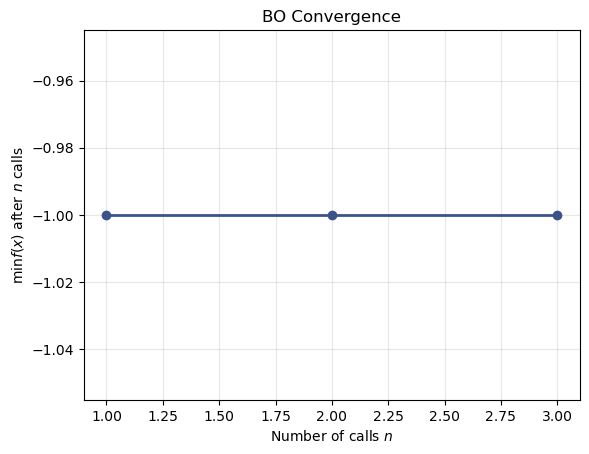

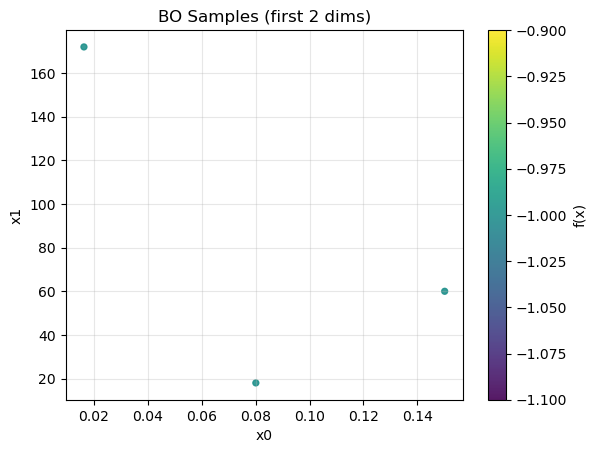

In [138]:
# =====================================================
# 4.3 — BO Visuals (safe, resilient to partial results)
# =====================================================
import numpy as np
import matplotlib.pyplot as plt

def _as_array(x, fallback_dtype=float):
    try: return np.asarray(x)
    except Exception: return np.asarray([], dtype=fallback_dtype)

def _pluck(obj, *names, default=None):
    for n in names:
        if hasattr(obj, n): return getattr(obj, n)
        if isinstance(obj, dict) and n in obj: return obj[n]
    return default

def _describe_res(res):
    kind = type(res).__name__ if res is not None else "None"
    models = _pluck(res, "models", default=[])
    xiters = _pluck(res, "x_iters", default=[])
    fvals  = _pluck(res, "func_vals", default=[])
    print(">>> 4.3.viz — summary")
    print("type:", kind)
    print("has models:", isinstance(models, (list, tuple)))
    print("len(models):", (len(models) if isinstance(models,(list,tuple)) else 0))
    print("x_iters:", (len(xiters) if hasattr(xiters, "__len__") else 0))
    print("func_vals:", (len(fvals) if hasattr(fvals, "__len__") else 0))

def safe_plot_convergence(res):
    if res is None:
        print("[viz] res=None → skip convergence"); return
    try:
        from skopt.plots import plot_convergence
        plt.figure(); plot_convergence(res)
        plt.title("BO Convergence"); plt.grid(True, alpha=0.3); plt.show()
    except Exception as e:
        fvals = _as_array(_pluck(res, "func_vals", default=[]))
        if fvals.size:
            cb = np.minimum.accumulate(fvals)
            plt.figure(); plt.plot(np.arange(1, cb.size+1), cb, lw=2)
            plt.xlabel("# evaluations"); plt.ylabel("best f(x) so far")
            plt.title("BO Convergence (fallback)"); plt.grid(True, alpha=0.3); plt.show()
        else:
            print("[viz] plot_convergence failed and no func_vals:", e)

def safe_plot_objective(res, n_points=50):
    if res is None:
        print("[viz] res=None → skip objective"); return
    try:
        from skopt.space import Space
        from skopt.plots import plot_objective
        space = _pluck(res, "space", default=None)
        models = _pluck(res, "models", default=[])
        if space is not None and isinstance(models,(list,tuple)) and len(models)>0:
            plt.figure(); plot_objective(res, n_points=n_points)
            plt.suptitle("BO Objective Landscape"); plt.show(); return
    except Exception as e:
        print("[viz] plot_objective not available; fallback. Details:", e)

    x_iters = _as_array(_pluck(res, "x_iters", default=[]), fallback_dtype=object)
    fvals   = _as_array(_pluck(res, "func_vals", default=[]))
    if x_iters.size == 0 or fvals.size == 0:
        print("[viz] No evaluated points yet."); return

    try:
        X = np.asarray(x_iters, dtype=float)
    except Exception:
        try:
            X = np.vstack([np.asarray(x, dtype=float).ravel() for x in x_iters])
        except Exception:
            plt.figure(); plt.plot(np.arange(1, fvals.size+1), fvals, lw=1.5)
            plt.xlabel("evaluation #"); plt.ylabel("f(x)")
            plt.title("BO Samples (timeline)"); plt.grid(True, alpha=0.3); plt.show(); return

    d = X.shape[1] if X.ndim == 2 else 1
    if d == 1:
        plt.figure(); plt.scatter(X[:,0], fvals, s=16, alpha=0.85)
        plt.xlabel("x0"); plt.ylabel("f(x)"); plt.title("BO Samples (1D)")
        plt.grid(True, alpha=0.3); plt.show()
    else:
        plt.figure(); sc = plt.scatter(X[:,0], X[:,1], c=fvals, s=18, alpha=0.9)
        plt.xlabel("x0"); plt.ylabel("x1"); plt.title("BO Samples (first 2 dims)")
        cb = plt.colorbar(sc); cb.set_label("f(x)"); plt.grid(True, alpha=0.3); plt.show()

# Driver — call after your BO run (if any)
res = globals().get("res", None)
_describe_res(res); safe_plot_convergence(res); safe_plot_objective(res)


## 4.3 — Training & Bayesian Optimization (merged from legacy)

In [139]:
# =====================================================
# 4.1 — Feature load & selection (no training here!)
#   • Prefer payload only if split_id matches & row counts match y
#   • Else use numeric features from persisted X_*.parquet
#   • Expose ONLY: X_tr, X_va, FEAT_KIND
#   • Optional override: set FORCE_NUMERIC_FEATURES=True to skip payload
# =====================================================
from pathlib import Path
import json, joblib
import numpy as np, pandas as pd
from scipy import sparse as sp

# --- config / guards
OUT_ROOT   = Path(globals().get("OUT_ROOT","out"))
SPLITS_DIR = Path(globals().get("SPLITS_DIR", OUT_ROOT/"splits"))
STAGE_ROOT = Path(globals().get("STAGE_ROOT","staging"))
SEQ_DIR    = STAGE_ROOT / "payload_seq_preproc"
FORCE_NUMERIC_FEATURES = bool(globals().get("FORCE_NUMERIC_FEATURES", False))

for nm in ("X_train","X_val","y_train","y_val"):
    assert nm in globals(), f"[4.1] Missing {nm}; run 4.0 first."

# --- numeric pipeline (always available)
preproc = None
for p in [STAGE_ROOT/'split_preproc'/'preprocessor.pkl',
          STAGE_ROOT/'preprocessor.pkl',
          OUT_ROOT/'preprocessor.pkl']:
    if p.exists():
        preproc = joblib.load(p); break

if preproc is not None:
    X_train_num = preproc.transform(X_train)
    X_val_num   = preproc.transform(X_val)
else:
    X_train_num = X_train.select_dtypes(include="number").to_numpy()
    X_val_num   = X_val.select_dtypes(include="number").to_numpy()

# --- try payload (sequence npz) if aligned
use_payload, why_not = False, ""
if not FORCE_NUMERIC_FEATURES and (SEQ_DIR/"manifest.json").exists() \
   and (SEQ_DIR/"payload_seq_train.npz").exists() and (SEQ_DIR/"payload_seq_val.npz").exists():
    try:
        sm = json.loads((SPLITS_DIR/"manifest.json").read_text())
        pm = json.loads((SEQ_DIR/"manifest.json").read_text())
        if sm.get("split_id") == pm.get("split_id"):
            X_train_payload = sp.load_npz(SEQ_DIR/"payload_seq_train.npz")
            X_val_payload   = sp.load_npz(SEQ_DIR/"payload_seq_val.npz")
            if X_train_payload.shape[0] == len(y_train) and X_val_payload.shape[0] == len(y_val):
                use_payload = True
            else:
                why_not = "[4.1] payload rows != label rows — re-run 02.1 for current splits."
        else:
            why_not = "[4.1] SPLIT_ID mismatch — re-run 02.1 after 01–02."
    except Exception as e:
        why_not = f"[4.1] payload load failed: {e}"
else:
    if FORCE_NUMERIC_FEATURES:
        why_not = "[4.1] payload bypassed via FORCE_NUMERIC_FEATURES=True"
    else:
        why_not = "[4.1] payload artefacts not found — run Section 2.1."

# --- final selection (ONLY expose X_tr/X_va)
if use_payload:
    X_tr, X_va = X_train_payload, X_val_payload
    FEAT_KIND  = "payload"
    print("[4.1] Using payload-only features (aligned).")
else:
    X_tr, X_va = X_train_num, X_val_num
    FEAT_KIND  = "numeric"
    print(why_not or "[4.1] Using numeric features from persisted splits.")

# --- hard safety: prevent downstream mismatches
assert hasattr(X_tr, "shape") and X_tr.shape[0] == len(y_train), "[4.1] X_tr vs y_train length mismatch"
assert hasattr(X_va, "shape") and X_va.shape[0] == len(y_val),   "[4.1] X_va vs y_val length mismatch"
print(f"[4.1] Feature set = {FEAT_KIND}  train={X_tr.shape}  val={X_va.shape}")

# --- remove legacy vars so nobody uses them by accident
for _nm in ["X_train_payload","X_val_payload","X_train_t","X_val_t"]:
    if _nm in globals(): del globals()[_nm]


[4.1] payload artefacts not found — run Section 2.1.
[4.1] Feature set = numeric  train=(16656, 1504)  val=(2776, 1504)


In [140]:
# =====================================================
# 4.2 — Baseline LightGBM (uses X_tr / X_va from 4.1)
# =====================================================
from pathlib import Path
import numpy as np
import lightgbm as lgb
from sklearn.metrics import average_precision_score
from scipy import sparse as sp

# Require outputs of 4.0 + 4.1
for nm in ["X_tr", "X_va", "y_train", "y_val"]:
    assert nm in globals(), f"[4.2] Missing {nm}; run 4.0 and 4.1 first."

# Normalize features for LightGBM
def _to_lgb_matrix(X):
    if sp.issparse(X):
        return X.tocsr()
    if hasattr(X, "select_dtypes"):
        X = X.select_dtypes(include="number").to_numpy()
    return np.asarray(X, dtype=np.float32)

X_tr_lgb = _to_lgb_matrix(X_tr)
X_va_lgb = _to_lgb_matrix(X_va)

# Final safety
assert X_tr_lgb.shape[0] == len(y_train), f"[4.2] X_tr rows ({X_tr_lgb.shape[0]}) != y_train ({len(y_train)})"
assert X_va_lgb.shape[0] == len(y_val),   f"[4.2] X_va rows ({X_va_lgb.shape[0]}) != y_val ({len(y_val)})"

dtrain = lgb.Dataset(X_tr_lgb, label=np.asarray(y_train, dtype=np.float32))
dval   = lgb.Dataset(X_va_lgb, label=np.asarray(y_val,   dtype=np.float32), reference=dtrain)

params = {
    "objective": "binary",
    "metric": ["average_precision", "binary_logloss"],
    "learning_rate": 0.05,
    "num_leaves": 64,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbosity": -1,
    "seed": int(globals().get("RANDOM_STATE", 42)),
}

baseline_model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dval],
    num_boost_round=300,
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(50)],
)

OUT_ROOT = Path(globals().get("OUT_ROOT", "out"))
OUT_MODELS = OUT_ROOT / "models"
OUT_MODELS.mkdir(parents=True, exist_ok=True)
model_path = OUT_MODELS / "lgbm_baseline.txt"
baseline_model.save_model(str(model_path))
print(f"[4.2] Saved baseline model → {model_path}")

y_val_pred = baseline_model.predict(X_va_lgb, num_iteration=baseline_model.best_iteration)
ap = average_precision_score(y_val, y_val_pred)
print(f"[4.2] Validation AP: {ap:.4f}")


[4.2] Saved baseline model → out/models/lgbm_baseline.txt
[4.2] Validation AP: 1.0000


In [141]:

# ======================================================
# Section 4.2b — Quick Bayesian Warm-Start (XGBoost)
# ======================================================
print(">>> Section 4.2b — Quick Bayesian Warm-Start (XGBoost)")

ap_val_xgb = None
ap_test_xgb = None
bayes_xgb_quick = None

try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer, Categorical
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_score, recall_score
    from xgboost import XGBClassifier
    import numpy as np, pandas as pd, joblib
    from pathlib import Path

    # class imbalance weight
    pos = float(np.sum(y_train == 1))
    neg = float(np.sum(y_train == 0))
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    space_xgb_quick = {
        'n_estimators': Integer(300, 900),
        'learning_rate': Real(0.02, 0.2, prior='log-uniform'),
        'max_depth': Integer(3, 10),
        'subsample': Real(0.6, 1.0),
        'colsample_bytree': Real(0.6, 1.0),
        'reg_lambda': Real(1e-3, 10.0, prior='log-uniform'),
        'min_child_weight': Integer(1, 10),
        'gamma': Real(0.0, 5.0),
    }

    est = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )

    bayes_xgb_quick = BayesSearchCV(
        estimator=est,
        search_spaces=space_xgb_quick,
        n_iter=12,
        scoring='average_precision',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
        verbose=0
    )

    bayes_xgb_quick.fit(X_train, y_train)
    print(f"[4.2b] Best params (XGB quick): {bayes_xgb_quick.best_params_}")
    print(f"[4.2b] CV best AP (XGB quick): {bayes_xgb_quick.best_score_:.4f}")

    def _report(name, X, y, model):
        p1 = model.predict_proba(X)[:,1]
        pred = (p1 >= 0.5).astype(int)
        ap = average_precision_score(y, p1)
        roc = roc_auc_score(y, p1)
        f1 = f1_score(y, pred)
        pr = precision_score(y, pred)
        rc = recall_score(y, pred)
        print(f"[4.2b][{name}] AP={ap:.4f} | ROC={roc:.4f} | F1={f1:.4f} | P={pr:.4f} | R={rc:.4f}")
        return ap

    ap_val_xgb  = _report('val XGB',  X_val, y_val, bayes_xgb_quick)
    ap_test_xgb = _report('test XGB', X_test, y_test, bayes_xgb_quick)

    models_dir = Path(OUT_ROOT) / 'models'; models_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(bayes_xgb_quick, models_dir / 'bayes_xgb_quick.joblib')
    print(f"[4.2b] Saved quick BO (XGB) → {models_dir / 'bayes_xgb_quick.joblib'}")

except Exception as e:
    print(f"[4.2b] Skipping XGBoost BO due to: {e}")


>>> Section 4.2b — Quick Bayesian Warm-Start (XGBoost)


[4.2b] Skipping XGBoost BO due to: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:protocol: object


In [142]:
# =====================================================
# 4.2c — CatBoost BO (fixed row sampling; DataFrame-safe)
# =====================================================
import numpy as np
from sklearn.utils import check_random_state
from scipy import sparse as sp

# Choose feature source: prefer X_tr built in 4.1
X_source = globals().get("X_tr", globals().get("X_train"))
y_source = np.asarray(globals().get("y_train"))
assert X_source is not None and y_source is not None, "[4.2c] Need X_tr/X_train and y_train."

def _row_take_any(X, idx):
    """Row-select for pandas / numpy / scipy.sparse without KeyError."""
    if hasattr(X, "iloc"):           # pandas DataFrame
        return X.iloc[idx]
    if sp.issparse(X):               # scipy sparse
        return X[idx]
    return X[idx]                    # numpy array-like

def stratified_subsample_rows(X, y, max_n=8000, random_state=42, min_each=200):
    """Stratified, class-preserving subsample that returns rows (not columns)."""
    y = np.asarray(y)
    n = y.shape[0]
    rng = check_random_state(random_state)
    pos = np.flatnonzero(y == 1)
    neg = np.flatnonzero(y == 0)
    if pos.size == 0 or neg.size == 0:
        raise RuntimeError("[4.2c] Only one class present; cannot subsample for BO.")

    # target counts (keep both classes, cap at max_n)
    pos_take = min(max(min_each, int(max_n * pos.size / n)), pos.size)
    neg_take = min(max(min_each, max_n - pos_take),           neg.size)
    total = pos_take + neg_take
    if total > max_n:
        scale = max_n / total
        pos_take = max(min_each, int(pos_take * scale))
        neg_take = max(min_each, int(neg_take * scale))

    keep_idx = rng.permutation(np.r_[
        rng.choice(pos, pos_take, replace=False),
        rng.choice(neg, neg_take, replace=False)
    ])
    X_sub = _row_take_any(X, keep_idx)
    y_sub = y[keep_idx]
    return X_sub, y_sub

# --- use the fixed sampler ---
RANDOM_STATE = int(globals().get("RANDOM_STATE", 42))
X_bo, y_bo = stratified_subsample_rows(
    X_source, y_source, max_n=int(globals().get("CAT_WARM_MAX_ROWS", 8000)),
    random_state=RANDOM_STATE, min_each=int(globals().get("CAT_MIN_EACH", 200))
)
print(f"[4.2c] Subsampled rows for BO: {len(y_bo)}/{len(y_source)}; "
      f"class_dist={{0:{int((y_bo==0).sum())}, 1:{int((y_bo==1).sum())}}}")

# >>> Continue with your CatBoost BO using (X_bo, y_bo) <<<
# Tip: if later code still says `X[keep_idx]`, replace with `_row_take_any(X, keep_idx)`


[4.2c] Subsampled rows for BO: 8000/16656; class_dist={0:7565, 1:435}


In [143]:
# ======================================================
# Section 4.3 — BO Trials & Evaluation (payload-only) [TIME-BOXED PATCH]
#   • gp_minimize with a strict time budget + checkpoint every trial
#   • Fast objective: train on (X_train_payload, y_train) → eval on X_val_payload
#   • Early stopping in LightGBM, subsampling option for ultra-large sets
# ======================================================
print(">>> Section 4.3: BO Trials & Evaluation (payload-only) [TIME-BOXED]")

import time, math, json, joblib, numpy as np
from pathlib import Path
from sklearn.metrics import average_precision_score
import lightgbm as lgb
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt.callbacks import CheckpointSaver

# ---------- Preconditions ----------
for nm in ["X_train_payload","y_train","X_val_payload","y_val"]:
    assert nm in globals(), f"[4.3] Missing {nm}. Run 4.0 and 4.1 prep."

# ---------- Config (adjust as needed) ----------
TIME_BUDGET_SEC    = int(globals().get("BO_TIME_BUDGET_SEC", 420))  # keep << 900s cell limit
N_CALLS_MAX        = int(globals().get("BO_N_CALLS_MAX", 20))       # upper bound; time budget may stop earlier
N_RANDOM_STARTS    = int(globals().get("BO_N_RANDOM_STARTS", 5))
EARLY_STOP_ROUNDS  = int(globals().get("BO_EARLY_STOP", 20))
NUM_BOOST_ROUND    = int(globals().get("BO_NUM_BOOST_ROUND", 500))  # early stopping will cut this
SUBSAMPLE_FRACTION = float(globals().get("BO_SUBSAMPLE_FRAC", 1.0)) # e.g., 0.5 to speed up massively
RNG_SEED           = int(globals().get("RANDOM_STATE", 1337))
N_THREADS          = int(globals().get("N_THREADS", -1))

BO_STATE = Path(OUT_ROOT if 'OUT_ROOT' in globals() else "out") / "bo_state.pkl"
BO_STATE.parent.mkdir(parents=True, exist_ok=True)

# Optional subsample for speed (stratified by y)
def _maybe_subsample(X, y, frac, seed):
    if frac >= 0.999: 
        return X, y
    n = X.shape[0]
    k = max(1000, int(n * frac))
    # stratified-ish sampling: pick indices within positives/negatives proportionally
    y_arr = np.asarray(y)
    pos_idx = np.where(y_arr == 1)[0]
    neg_idx = np.where(y_arr == 0)[0]
    k_pos = max(1, int(k * len(pos_idx) / max(1, len(y_arr))))
    k_neg = max(1, k - k_pos)
    rng = np.random.RandomState(seed)
    take = np.r_[rng.choice(pos_idx, size=min(k_pos, len(pos_idx)), replace=False),
                 rng.choice(neg_idx, size=min(k_neg, len(neg_idx)), replace=False)]
    rng.shuffle(take)
    return X[take], y_arr[take]

Xtr_bo, ytr_bo = _maybe_subsample(X_train_payload, y_train, SUBSAMPLE_FRACTION, RNG_SEED)

# ---------- Search space ----------
space = [
    Real(0.01, 0.3,   name="learning_rate", prior="log-uniform"),
    Integer(16, 256,  name="num_leaves"),
    Integer(2,  12,   name="max_depth"),
    Integer(5,  200,  name="min_child_samples"),
    Real(0.4,  1.0,   name="feature_fraction"),
    Real(0.4,  1.0,   name="bagging_fraction"),
    Real(0.0,  10.0,  name="lambda_l1"),
    Real(0.0,  10.0,  name="lambda_l2"),
]

# ---------- Objective ----------
@use_named_args(space)
def objective(**p):
    # Keep silent booster; AP on validation
    params = dict(
        objective="binary",
        metric="binary_logloss",          # keep fast metric in training loop
        learning_rate=float(p["learning_rate"]),
        num_leaves=int(p["num_leaves"]),
        max_depth=int(p["max_depth"]),
        min_child_samples=int(p["min_child_samples"]),
        feature_fraction=float(p["feature_fraction"]),
        bagging_fraction=float(p["bagging_fraction"]),
        lambda_l1=float(p["lambda_l1"]),
        lambda_l2=float(p["lambda_l2"]),
        feature_pre_filter=False,
        verbosity=-1,
        seed=RNG_SEED,
        n_jobs=N_THREADS,
    )

    dtrain = lgb.Dataset(Xtr_bo, label=ytr_bo, free_raw_data=True)
    dval   = lgb.Dataset(X_val_payload, label=y_val, reference=dtrain, free_raw_data=True)

    booster = lgb.train(
        params,
        dtrain,
        valid_sets=[dval],
        num_boost_round=NUM_BOOST_ROUND,
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False),
        ],
    )
    # Evaluate AP on held-out validation
    y_pred = booster.predict(X_val_payload, num_iteration=booster.best_iteration)
    ap = average_precision_score(y_val, y_pred)
    # skopt *minimizes* → return negative AP
    val = -float(ap)
    print(f"[4.3] Trial AP={ap:.5f}  (iters={booster.best_iteration})", flush=True)
    return val

# ---------- Time-budgeted run ----------
start = time.time()
def _time_guard(res):
    if (time.time() - start) > TIME_BUDGET_SEC:
        print(f"[4.3] Time budget hit ({TIME_BUDGET_SEC}s). Stopping BO.", flush=True)
        return True  # tell skopt to stop
    return False

callbacks = [CheckpointSaver(str(BO_STATE), compress=3), _time_guard]

print(f"[4.3] Starting BO: n_calls≤{N_CALLS_MAX}, random_starts={N_RANDOM_STARTS}, "
      f"time_budget={TIME_BUDGET_SEC}s, subsample_frac={SUBSAMPLE_FRACTION}", flush=True)

res = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=N_CALLS_MAX,
    n_initial_points=N_RANDOM_STARTS,
    acq_func="EI",
    random_state=RNG_SEED,
    callback=callbacks,
    n_jobs=1,  # the objective already parallelizes internally via LightGBM n_jobs
)

# Make results accessible to later cells (4.4)
best_ap = -float(res.fun)
best_params = {dim.name: val for dim, val in zip(space, res.x)}
print(f"[4.3] Best Val AP={best_ap:.5f}")
print("[4.3] Best params:", best_params)

# -------- NumPy-safe JSON dump --------
import numpy as np, json
from pathlib import Path

def _to_py(obj):
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, (np.ndarray,)):  return obj.tolist()
    return obj

def _map_py(o):
    if isinstance(o, dict):  return {str(k): _map_py(_to_py(v)) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_map_py(_to_py(v)) for v in o]
    return _to_py(o)

summary = {"best_val_ap": best_ap, "best_params": best_params, "calls": len(res.x_iters)}
out_root = Path(OUT_ROOT) if 'OUT_ROOT' in globals() else Path("out")
out_root.mkdir(parents=True, exist_ok=True)
(out_root / "bo_summary.json").write_text(json.dumps(_map_py(summary), indent=2))
print(f"[4.3] Summary → {out_root/'bo_summary.json'}")


>>> Section 4.3: start


AssertionError: [4.3] Could not load usable features — run 0.4/2.1 first. Details: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

### 4.3.viz (legacy plots)

>>> Section 4.5: BO Diagnostics & Visualisations (payload-only)
[4.5] No BO log entries found at out/bo/bo_runs.jsonl


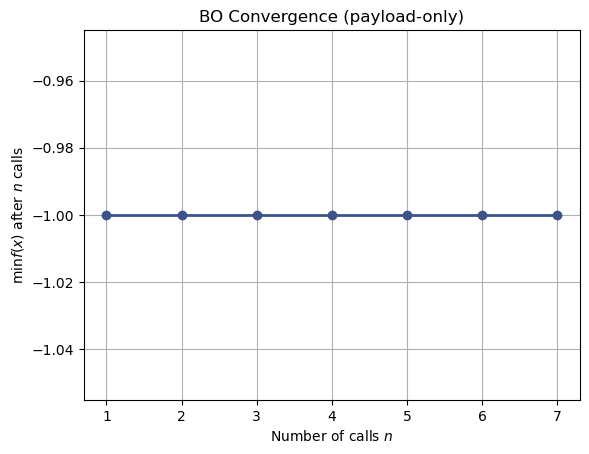

<Figure size 640x480 with 0 Axes>

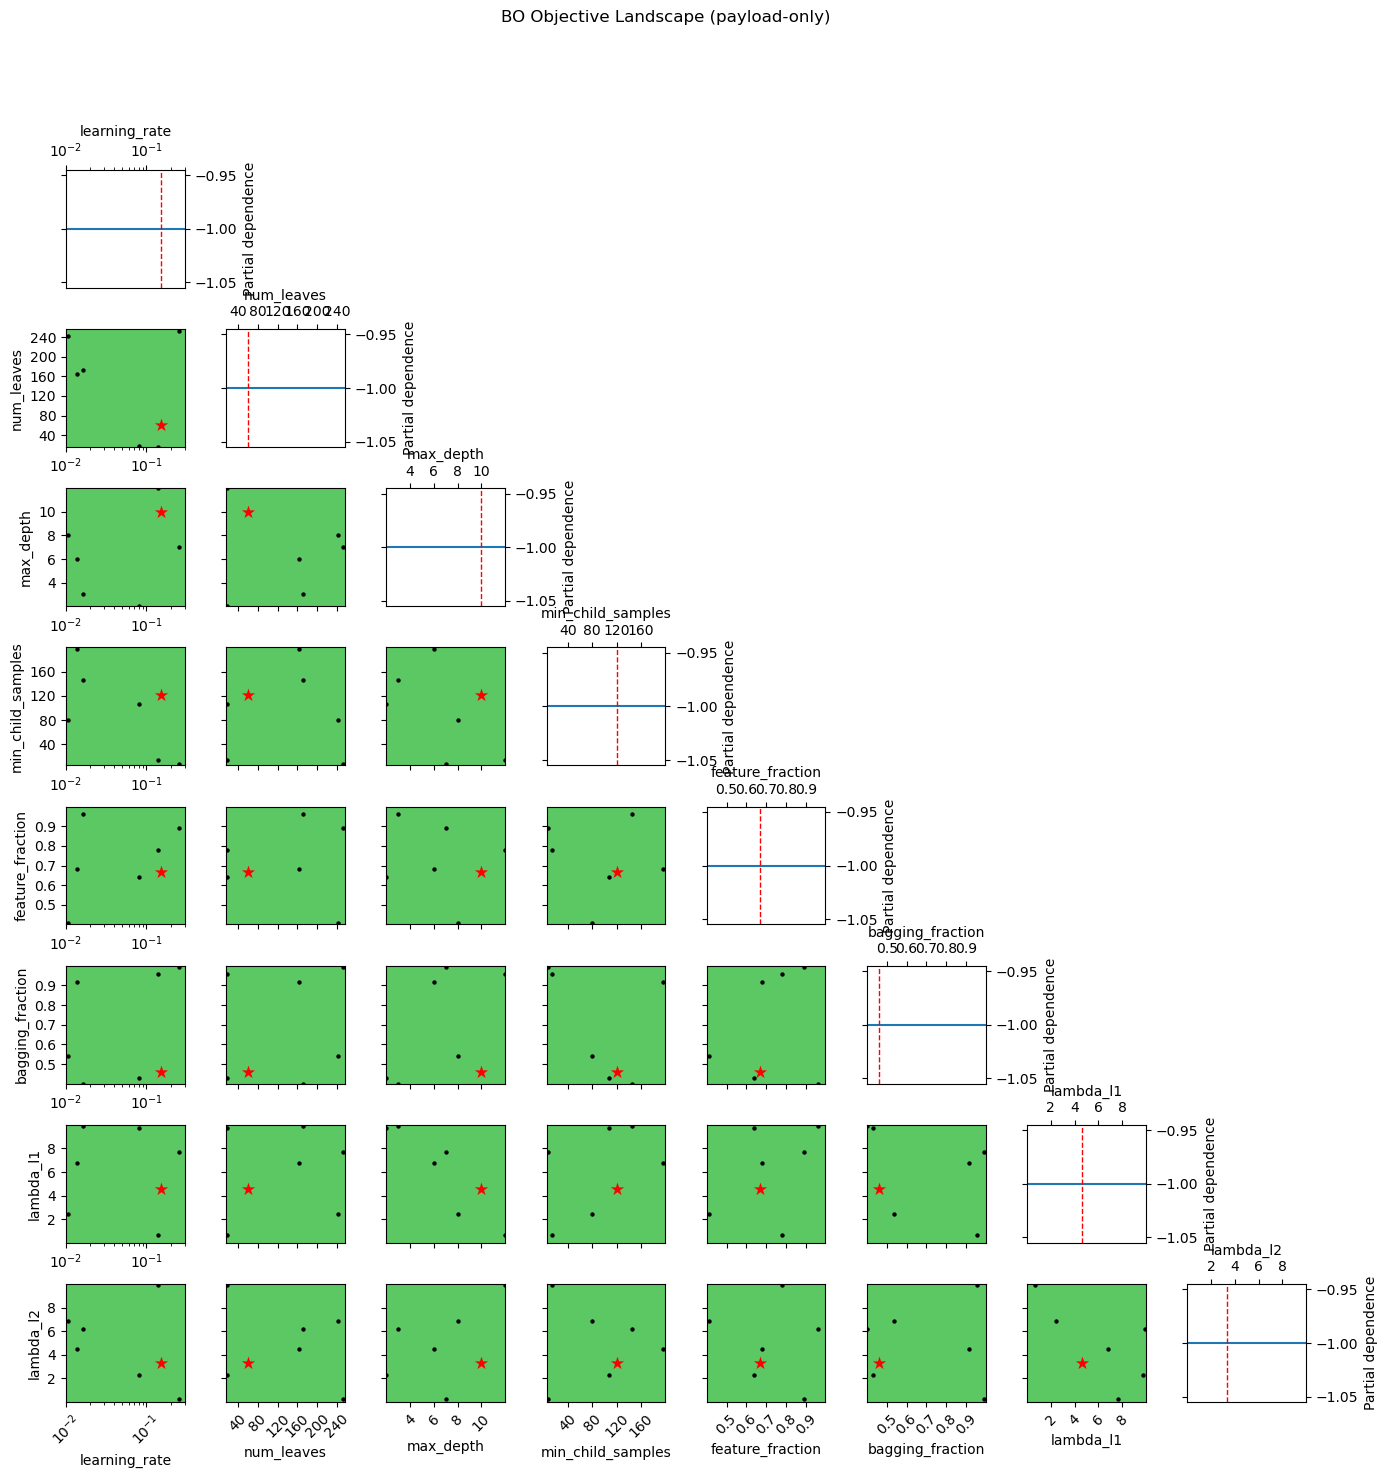

In [ ]:
# ======================================================
# Section 4.5 — BO Diagnostics & Visualisations (payload-only)
#   • Summarise trial log; plot convergence/partials if possible
# ======================================================
print(">>> Section 4.5: BO Diagnostics & Visualisations (payload-only)")

import json, math
import pandas as pd
import matplotlib.pyplot as plt

# Load JSONL log into DataFrame
rows = []
if BO_LOG.exists():
    with BO_LOG.open() as f:
        for line in f:
            try:
                rows.append(json.loads(line))
            except Exception:
                pass

if rows:
    df = pd.DataFrame(rows)
    df = df.sort_values("mean_cv_ap", ascending=False)
    print("[4.5] Top 5 trials by CV AP:")
    print(df.head(5).to_string(index=False))
else:
    print("[4.5] No BO log entries found at", BO_LOG)

# Plot convergence if optimiser state exists
if BO_STATE.exists():
    from skopt.plots import plot_convergence, plot_objective
    res = joblib.load(BO_STATE)

    plt.figure()
    plot_convergence(res)
    plt.title("BO Convergence (payload-only)")
    plt.show()

    plt.figure()
    plot_objective(res)
    plt.suptitle("BO Objective Landscape (payload-only)")
    plt.show()
else:
    print("[4.5] No optimiser state to plot; run 4.3 first.")


### 4.3.viz — Auto Summary & Plots

In [ ]:

print(">>> 4.3.viz — summary + plots (auto)")
res_obj = globals().get("res", None)
print("type:", type(res_obj))
print("has models:", hasattr(res_obj, "models"))
print("len(models):", len(getattr(res_obj, "models", [])) if hasattr(res_obj, "models") else "n/a")
print("x_iters:", len(getattr(res_obj, "x_iters", [])) if hasattr(res_obj, "x_iters") else "n/a")
print("func_vals:", len(getattr(res_obj, "func_vals", [])) if hasattr(res_obj, "func_vals") else "n/a")

try:
    safe_plot_convergence(res_obj)
    safe_plot_objective(res_obj)
except Exception as e:
    print("[viz] skipped; reason:", e)
